In [12]:
import os
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import mlflow.sklearn

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

print("MLflow version:", mlflow.__version__)

MLflow version: 3.16.0


In [13]:
TRACKING_URI = "sqlite:///mlruns.db"

mlflow.set_tracking_uri(TRACKING_URI)

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: sqlite:///mlruns.db


In [14]:
#command to start server
#mlflow server --backend-store-uri sqlite:///mlruns.db --port 5000

In [15]:
data=load_breast_cancer()
x=pd.DataFrame(data.data,columns=data.feature_names)
y=pd.Series(data.target,name="targt")

In [16]:
x.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [17]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.3,random_state=42)

In [18]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [ ]:
model=LogisticRegression(C=1,random_state=42)
model.fit(X_train_scaled,y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [20]:
y_pred=model.predict(x_test_scaled)

In [26]:
c_values=[.01,.1,1,10,100]
for c in c_values:
    with mlflow.start_run(run_name="base_line_logistic_regression") as run:
        mlflow.log_param("modeltype","logistic regression")
        mlflow.log_param("c",c)
        model=LogisticRegression(C=c,random_state=42)
        model.fit(X_train_scaled,y_train)
        y_pred=model.predict(x_test_scaled)
        mlflow.log_param("max_iter",1000)
        baseline_accuracy=accuracy_score(y_test,y_pred)
        baseline_precision=precision_score(y_test,y_pred)
        baseline_recall=recall_score(y_test,y_pred)
        baseline_f1_score=f1_score(y_test,y_pred)
        mlflow.log_metric("accuracy",baseline_accuracy)
        mlflow.log_metric("presision",baseline_precision)
        mlflow.log_metric("recall",baseline_recall)
        mlflow.log_metric("f1 score",baseline_f1_score)
        mlflow.sklearn.log_model(model,"base linemodel")

    print(f"Accuracy: {baseline_accuracy*100:.2f}%")
    print(f"Precision: {baseline_precision:.2f}")
    print(f"Recall: {baseline_recall:.2f}")
    print(f"F1-Score: {baseline_f1_score:.2f}")

print("run id", run.info.run_id)

2026/09/19 12:31:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Accuracy: 95.91%
Precision: 0.94
Recall: 1.00
F1-Score: 0.97


2026/09/19 12:31:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Accuracy: 98.83%
Precision: 0.98
Recall: 1.00
F1-Score: 0.99


2026/09/19 12:32:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Accuracy: 98.25%
Precision: 0.99
Recall: 0.98
F1-Score: 0.99


2026/09/19 12:32:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Accuracy: 97.66%
Precision: 0.99
Recall: 0.97
F1-Score: 0.98


2026/09/19 12:32:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Accuracy: 95.91%
Precision: 0.99
Recall: 0.94
F1-Score: 0.97
run id 32ed305db634495a98dcc6f2cec4be7a


In [22]:
experiment_name="brest canser classification"
experiment=mlflow.set_experiment(experiment_name)
print("experiment id",experiment.experiment_id)
print("experiment name",experiment.name)


experiment id 1
experiment name brest canser classification


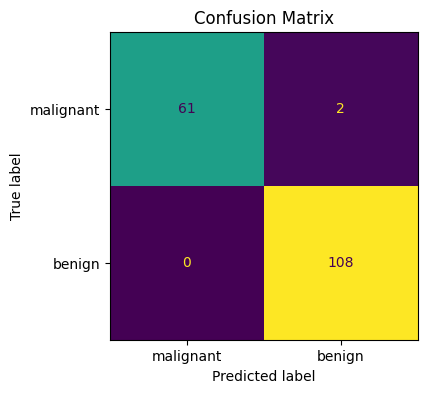

2026/09/19 13:19:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run ID : f905a35bd2c942eeb2e3b7a17df1643c
Accuracy : 98.83%
Macro F1  : 0.9873
Weighted F1: 0.9883


In [27]:
with mlflow.start_run(run_name="classification report") as run:
    model = LogisticRegression(C=.1, max_iter=1000)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(x_test_scaled)

    # --- Classification report ---
    report = classification_report(y_test, pred, output_dict=True)
    report_path = "classification_report.json"
    with open(report_path, "w") as f:
        json.dump(report, f, indent=2)
    mlflow.log_artifact(report_path)

    # --- Log scalar metrics ---
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("C", 0.1)
    mlflow.log_param("max_iter", 1000)
    mlflow.log_metric("accuracy", report["accuracy"])
    for label in ["0", "1"]:
        mlflow.log_metric(f"precision_class_{label}", report[label]["precision"])
        mlflow.log_metric(f"recall_class_{label}",    report[label]["recall"])
        mlflow.log_metric(f"f1_class_{label}",        report[label]["f1-score"])
    mlflow.log_metric("macro_f1",    report["macro avg"]["f1-score"])
    mlflow.log_metric("weighted_f1", report["weighted avg"]["f1-score"])

    # --- Confusion matrix plot ---
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, pred,
                                            display_labels=data.target_names,
                                            ax=ax, colorbar=False)
    ax.set_title("Confusion Matrix")
    cm_path = "confusion_matrix.png"
    fig.savefig(cm_path, bbox_inches="tight")
    plt.show()
    mlflow.log_artifact(cm_path)

    # --- Log model ---
    mlflow.sklearn.log_model(model, "logistic_regression_model")

    print(f"Run ID : {run.info.run_id}")
    print(f"Accuracy : {report['accuracy']*100:.2f}%")
    print(f"Macro F1  : {report['macro avg']['f1-score']:.4f}")
    print(f"Weighted F1: {report['weighted avg']['f1-score']:.4f}")